In [9]:
from random import uniform, shuffle
import matplotlib.pyplot as plt
import os
from math import ceil

# =============== GENERATOR ===============
def generate_data(func=None, n_points=500, x_range=(0, 100), y_range=(-10, 10)):
	data = []
	for _ in range(n_points):
		a = uniform(*x_range)
		b = uniform(*y_range)
		if func is None:
			label = 0 if a < (x_range[0] + x_range[1]) / 2 else 1
		else:
			label = 0 if b < func(a) else 1
		data.append((a, b, label))
	shuffle(data)
	return data

# k = ceil(uniform(-10, 10))
# c = ceil(uniform(-20, 20))
# ep = ceil(uniform(50, 300))
data = generate_data(func=lambda x: 0.5 * x + 10, n_points=100, x_range=(-500, 500), y_range=(-100, 100))





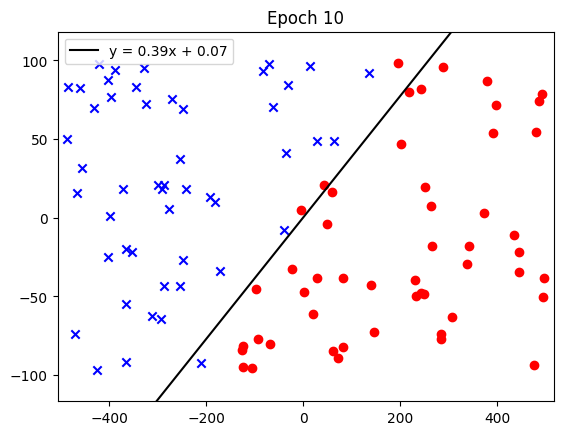

In [ ]:
# =============== PERCEPTRON ===============
import pickle

class Perceptron:
	def __init__(self, input_size, learning_rate=0.1):
		self.weights = [uniform(-1, 1) for _ in range(input_size)]
		self.bias = uniform(-1, 1)
		self.lr = learning_rate
		self.train_x = None
		self.train_y = None

	def train(self, x, y, epochs=25, save_frames=True, dump_name="default", frame_interval=5, save_mode = "off"):
		dumps_dir = "dumps"
		frames_dir = os.path.join("frames", dump_name)
		self.train_x = x
		self.train_y = y
		

		if save_frames and not os.path.exists(frames_dir):
			os.makedirs(frames_dir)

		if not os.path.exists(dumps_dir):
			os.makedirs(dumps_dir)

		for epoch in range(epochs):
			for inputs, label in zip(x, y):
				prediction = self.predict(inputs)
				error = label - prediction
				for i in range(len(self.weights)):
					self.weights[i] += self.lr * error * inputs[i]
				self.bias += self.lr * error
			save_path = os.path.join(frames_dir, f"epoch_{epoch+1:03}.png")
			self.plot_decision_boundary(x, y, epoch + 1, save_path=save_path)

		if save_mode == "on":
			model_path = "dumps\\" + dump_name
			if not model_path.endswith(".pkl"):
				model_path += ".pkl"
			with open(model_path, "wb") as f:
				pickle.dump({
					'weights': self.weights,
					'bias': self.bias,
					'train_x': self.train_x,
					'train_y': self.train_y
				}, f)

	def load_model(self, filename):
		with open(filename, "rb") as f:
			data = pickle.load(f)
			self.weights = data['weights']
			self.bias = data['bias']
			self.train_x = data['train_x']
			self.train_y = data['train_y']
	def plot_decision_boundary(self, x, y, epoch, save_path=None):
		plt.clf()
		for (xi, yi), label in zip(x, y):
			plt.scatter(xi, yi, color='red' if label == 0 else 'blue', marker='o' if label == 0 else 'x')
	
		if self.weights[1] != 0:
			x_vals = [min(pt[0] for pt in x) - 10, max(pt[0] for pt in x) + 10]
			y_vals = [-(self.weights[0] * xv + self.bias) / self.weights[1] for xv in x_vals]
	
			eq_text = f"y = {-self.weights[0]/self.weights[1]:.2f}x + {-self.bias/self.weights[1]:.2f}"
			plt.plot(x_vals, y_vals, 'k-', label=eq_text)
	
		plt.title(f"Epoch {epoch}")
		plt.xlim(min(pt[0] for pt in x) - 20, max(pt[0] for pt in x) + 20)
		plt.ylim(min(pt[1] for pt in x) - 20, max(pt[1] for pt in x) + 20)
	
		plt.legend()
		if save_path:
			plt.savefig(save_path)
		else:
			plt.pause(0.001)
			
	def predict(self, inputs):
		total = sum(w * xi for w, xi in zip(self.weights, inputs)) + self.bias
		return 1 if total >= 0 else 0

# x = []
# y = []
# data = []
# for _ in range(50):  # класс 0
# 	a = uniform(0, 50)
# 	b = uniform(-10, 11)
# 	data.append((a, b, 0))

# for _ in range(50):  # класс 1
# 	a = uniform(101, 201)
# 	b = uniform(-10, 11)
# 	data.append((a, b, 1))

# shuffle(data)


x = [[a, b] for a, b, _ in data]
y = [label for _, _, label in data]
p = Perceptron(input_size=2, learning_rate=1)
p.train(x, y, epochs=10, dump_name=f"{1}", save_mode="on")